In [3]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import os

# ============================================================
# 1. CUTFLOW TRACKER
# ============================================================
class CutflowTracker:
    def __init__(self):
        self.steps = []
        self.raw_counts = {}
        self.weighted_counts = {}

    def update(self, step_name, events):
        if step_name not in self.steps: self.steps.append(step_name)
        n_raw = len(events)
        w_sum = ak.sum(np.ones(len(events))) if len(events) > 0 else 0.0
        self.raw_counts[step_name] = self.raw_counts.get(step_name, 0) + n_raw
        self.weighted_counts[step_name] = self.weighted_counts.get(step_name, 0.0) + w_sum

    def summary(self):
        """Returns a dictionary of the raw counts for the all_results dict."""
        return {step: self.raw_counts[step] for step in self.steps}

    def save_csv(self, process_name, output_dir):
        data = []
        if not self.steps: return
        initial_w = self.weighted_counts.get(self.steps[0], 1.0)
        if initial_w == 0: initial_w = 1.0 
        prev_w = initial_w

        for step in self.steps:
            raw = self.raw_counts[step]
            weighted = self.weighted_counts[step]
            abs_eff = (weighted / initial_w) * 100
            rel_eff = (weighted / prev_w) * 100 if prev_w > 0 else 0
            
            data.append({
                "Step": step, "Raw Events": raw, "Weighted Yield": weighted,
                "Absolute Eff (%)": f"{abs_eff:.2f}", "Relative Eff (%)": f"{rel_eff:.2f}"
            })
            prev_w = weighted
            
        df = pd.DataFrame(data)
        os.makedirs(output_dir, exist_ok=True)
        df.to_csv(os.path.join(output_dir, f"cutflow_{process_name}.csv"), index=False)
        print(f"Saved cutflow for {process_name}")

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================
def delta_r(eta1, phi1, eta2, phi2):
    """Calculates angular distance ΔR with proper phi wrapping."""
    deta = eta1 - eta2
    dphi = np.abs(phi1 - phi2)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    return np.sqrt(deta**2 + dphi**2)

def apply_overlap_removal(events):
    """
    Applies overlap removal criteria using purely flat parallel arrays.
    """
    jet_pt     = events["valid_jet_pt"]
    jet_eta    = events["valid_jet_eta"]
    jet_phi    = events["valid_jet_phi"]
    jet_trk    = events["valid_jet_trk"] 
    jet_btag   = events["valid_jet_btag"]
    jet_tautag = events["valid_jet_tautag"]

    ele_pt  = events["valid_elec_pt"]
    ele_eta = events["valid_elec_eta"]
    ele_phi = events["valid_elec_phi"]

    mu_pt   = events["valid_muon_pt"]
    mu_eta  = events["valid_muon_eta"]
    mu_phi  = events["valid_muon_phi"]

    # 1. JET-ELECTRON OR: Remove jet if ΔR(jet, e) < 0.2
    je_eta_j, je_eta_e = ak.unzip(ak.cartesian((jet_eta, ele_eta), nested=True))
    je_phi_j, je_phi_e = ak.unzip(ak.cartesian((jet_phi, ele_phi), nested=True))
    
    dR_je = delta_r(je_eta_j, je_phi_j, je_eta_e, je_phi_e)
    jet_pass_e = ak.all(dR_je >= 0.2, axis=-1)
    
    jet_pt, jet_eta, jet_phi = jet_pt[jet_pass_e], jet_eta[jet_pass_e], jet_phi[jet_pass_e]
    jet_trk, jet_btag, jet_tautag = jet_trk[jet_pass_e], jet_btag[jet_pass_e], jet_tautag[jet_pass_e]

    # 2. JET-MUON OR: Remove jet if ΔR(jet, mu) < 0.4 AND jet tracks < 3
    jm_eta_j, jm_eta_m = ak.unzip(ak.cartesian((jet_eta, mu_eta), nested=True))
    jm_phi_j, jm_phi_m = ak.unzip(ak.cartesian((jet_phi, mu_phi), nested=True))
    
    dR_jm = delta_r(jm_eta_j, jm_phi_j, jm_eta_m, jm_phi_m)
    jet_near_mu = ak.any(dR_jm < 0.4, axis=-1)
    
    jet_pass_mu = ~(jet_near_mu & (jet_trk < 3))
    
    surv_jet_pt, surv_jet_eta, surv_jet_phi = jet_pt[jet_pass_mu], jet_eta[jet_pass_mu], jet_phi[jet_pass_mu]
    surv_jet_btag, surv_jet_tautag = jet_btag[jet_pass_mu], jet_tautag[jet_pass_mu]

    # 3. ELECTRON-JET OR: Remove e if ΔR(e, surviving_jet) < 0.4
    ej_eta_e, ej_eta_j = ak.unzip(ak.cartesian((ele_eta, surv_jet_eta), nested=True))
    ej_phi_e, ej_phi_j = ak.unzip(ak.cartesian((ele_phi, surv_jet_phi), nested=True))
    
    dR_ej = delta_r(ej_eta_e, ej_phi_e, ej_eta_j, ej_phi_j)
    ele_pass_j = ak.all(dR_ej >= 0.4, axis=-1)
    
    surv_ele_pt, surv_ele_eta, surv_ele_phi = ele_pt[ele_pass_j], ele_eta[ele_pass_j], ele_phi[ele_pass_j]

    # 4. MUON-JET OR: Remove mu if ΔR(mu, surviving_jet) < 0.4
    mj_eta_m, mj_eta_j = ak.unzip(ak.cartesian((mu_eta, surv_jet_eta), nested=True))
    mj_phi_m, mj_phi_j = ak.unzip(ak.cartesian((mu_phi, surv_jet_phi), nested=True))
    
    dR_mj = delta_r(mj_eta_m, mj_phi_m, mj_eta_j, mj_phi_j)
    mu_pass_j = ak.all(dR_mj >= 0.4, axis=-1)
    
    surv_mu_pt, surv_mu_eta, surv_mu_phi = mu_pt[mu_pass_j], mu_eta[mu_pass_j], mu_phi[mu_pass_j]

    # 5. Save the cleaned arrays back to the event
    events["post_OR_jet_pt"]     = surv_jet_pt
    events["post_OR_jet_eta"]    = surv_jet_eta
    events["post_OR_jet_phi"]    = surv_jet_phi
    events["post_OR_jet_btag"]   = surv_jet_btag
    events["post_OR_jet_tautag"] = surv_jet_tautag

    events["post_OR_elec_pt"]  = surv_ele_pt
    events["post_OR_elec_eta"] = surv_ele_eta
    events["post_OR_elec_phi"] = surv_ele_phi

    events["post_OR_muon_pt"]  = surv_mu_pt
    events["post_OR_muon_eta"] = surv_mu_eta
    events["post_OR_muon_phi"] = surv_mu_phi

    return events

# ============================================================
# 3. EVENT PRESELECTION
# ============================================================
def apply_preselection(events, tracker):
    if len(events) == 0: return events
    tracker.update("Initial Raw Batch", events)
    # Add weights later
    
    # Prevent shape mismatch for MET later
    try:
        events["met_standard_pt"]  = events["MissingET/MissingET.MET"][:, 0]
        events["met_standard_phi"] = events["MissingET/MissingET.Phi"][:, 0]
    except IndexError:
        events["met_standard_pt"]  = events["MissingET/MissingET.MET"]
        events["met_standard_phi"] = events["MissingET/MissingET.Phi"]

    # ====================================================================
    # 1. KINEMATIC SELECTION
    # ====================================================================

    events["valid_jet_pt"]  = events["Jet/Jet.PT"]
    events["valid_jet_eta"] = events["Jet/Jet.Eta"]
    events["valid_jet_phi"] = events["Jet/Jet.Phi"]
    events["valid_jet_trk"] = events["Jet/Jet.NCharged"]
    events["valid_jet_btag"] = events["Jet/Jet.BTag"]
    events["valid_jet_tautag"] = events["Jet/Jet.TauTag"]

    raw_ele_pt = events["Electron/Electron.PT"]
    raw_ele_eta = events["Electron/Electron.Eta"]
    raw_ele_phi = events["Electron/Electron.Phi"]

    ele_base_mask = (raw_ele_pt > 7) & (np.abs(raw_ele_eta) < 2.5)

    events["valid_elec_pt"]  = raw_ele_pt[ele_base_mask]
    events["valid_elec_eta"] = raw_ele_eta[ele_base_mask]
    events["valid_elec_phi"] = raw_ele_phi[ele_base_mask]

    raw_mu_pt = events["Muon/Muon.PT"]
    raw_mu_eta = events["Muon/Muon.Eta"]
    raw_mu_phi = events["Muon/Muon.Phi"]

    mu_base_mask = (raw_mu_pt > 7) & (np.abs(raw_mu_eta) < 2.5)
    events["valid_muon_pt"]  = raw_mu_pt[mu_base_mask]
    events["valid_muon_eta"] = raw_mu_eta[mu_base_mask]
    events["valid_muon_phi"] = raw_mu_phi[mu_base_mask]

    events = apply_overlap_removal(events)
    tracker.update("Overlap Removal", events)
    if len(events) == 0: return events

    eta_mask = np.abs(events["post_OR_jet_eta"]) < 2.8
    pt_mask = events["post_OR_jet_pt"] > 30
    sig_jet_mask = eta_mask & pt_mask

    events["signal_jet_pt"]  = events["post_OR_jet_pt"][sig_jet_mask]
    events["signal_jet_eta"] = events["post_OR_jet_eta"][sig_jet_mask]
    events["signal_jet_phi"] = events["post_OR_jet_phi"][sig_jet_mask]
    events["signal_jet_btag"] = events["post_OR_jet_btag"][sig_jet_mask]
    events["signal_jet_tautag"] = events["post_OR_jet_tautag"][sig_jet_mask]

    has_at_least_2 = ak.num(events["signal_jet_pt"]) >= 2
    events = events[has_at_least_2]
    if len(events) == 0: return events
    events = events[events["signal_jet_pt"][:, 0] > 250]

    tracker.update("Signal Jet Kinematic Selection", events)

    # ====================================================================
    # 4. LARGE-R JET REQUIREMENT 
    # ====================================================================
    ljet_pt = events["FatJet/FatJet.PT"]
    events = events[ak.num(ljet_pt) >= 2]
    
    tracker.update("Large-R Jet >= 2", events)
    if len(events) == 0: return events
    raw_taus = events["FatJet.Tau[5]"]
    tau1, tau2, tau3 = raw_taus[:, :, 0], raw_taus[:, :, 1], raw_taus[:, :, 2]
    
    events["tau21_j1"] = tau2[:, 0] / ak.where(tau1[:, 0] == 0, 1.0, tau1[:, 0])
    events["tau32_j1"] = tau3[:, 0] / ak.where(tau2[:, 0] == 0, 1.0, tau2[:, 0])
    events["tau21_j2"] = tau2[:, 1] / ak.where(tau1[:, 1] == 0, 1.0, tau1[:, 1])
    events["tau32_j2"] = tau3[:, 1] / ak.where(tau2[:, 1] == 0, 1.0, tau2[:, 1])

    # ====================================================================
    # 5. B-JET VETO / TAGGING
    # ====================================================================
    n_bjets = ak.sum(events["valid_jet_btag"] == 1, axis=1)
    events["n_bjets"] = n_bjets
    events = events[n_bjets <= 1]

    tracker.update("B-jet Veto", events)
    if len(events) == 0: return events

    # ====================================================================
    # 6. SIGNAL LEPTON REQUIREMENTS (Post-OR)
    # ====================================================================
    ele_eta_abs = np.abs(events["post_OR_elec_eta"])
    ele_sig_mask = (events["post_OR_elec_pt"] > 7) & \
                   (ele_eta_abs < 2.5) & \
                   ~((ele_eta_abs > 1.37) & (ele_eta_abs < 1.52))
    
    events["signal_elec_pt"]  = events["post_OR_elec_pt"][ele_sig_mask]
    events["signal_elec_eta"] = events["post_OR_elec_eta"][ele_sig_mask]
    events["signal_elec_phi"] = events["post_OR_elec_phi"][ele_sig_mask]

    mu_sig_mask = (events["post_OR_muon_pt"] > 7) & (np.abs(events["post_OR_muon_eta"]) < 2.5)

    events["signal_muon_pt"]  = events["post_OR_muon_pt"][mu_sig_mask]
    events["signal_muon_eta"] = events["post_OR_muon_eta"][mu_sig_mask]
    events["signal_muon_phi"] = events["post_OR_muon_phi"][mu_sig_mask]

    # ====================================================================
    # 7. MET REBUILDING (Excluding Muons)
    # ====================================================================
    sum_j_px = ak.sum(events["signal_jet_pt"] * np.cos(events["signal_jet_phi"]), axis=1)
    sum_j_py = ak.sum(events["signal_jet_pt"] * np.sin(events["signal_jet_phi"]), axis=1)

    sum_e_px = ak.sum(events["signal_elec_pt"] * np.cos(events["signal_elec_phi"]), axis=1)
    sum_e_py = ak.sum(events["signal_elec_pt"] * np.sin(events["signal_elec_phi"]), axis=1)

    sum_mu_px = ak.sum(events["signal_muon_pt"] * np.cos(events["signal_muon_phi"]), axis=1)
    sum_mu_py = ak.sum(events["signal_muon_pt"] * np.sin(events["signal_muon_phi"]), axis=1)

    soft_px = events["met_standard_pt"] * np.cos(events["met_standard_phi"]) - sum_j_px - sum_e_px - sum_mu_px
    soft_py = events["met_standard_pt"] * np.sin(events["met_standard_phi"]) - sum_j_py - sum_e_py - sum_mu_py

    # --- 1. THE TRIGGER PROXY (Standard Full MET) ---
    std_met_px = -(sum_j_px + sum_e_px + sum_mu_px + soft_px)
    std_met_py = -(sum_j_py + sum_e_py + sum_mu_py + soft_py)
    events["met_standard_pt"] = np.sqrt(std_met_px**2 + std_met_py**2)

    # --- 2. YOUR ANALYSIS MET (Muons treated as invisible) ---
    met_px = -(sum_j_px + sum_e_px + soft_px)
    met_py = -(sum_j_py + sum_e_py + soft_py)
    events["met_recalc_pt"]  = np.sqrt(met_px**2 + met_py**2)
    events["met_recalc_phi"] = np.arctan2(met_py, met_px)

    # ====================================================================
    # 7.5 TRIGGER PROXY CUT
    # ====================================================================
    # Force the event to have enough REAL missing energy to fire the MET trigger
    events = events[events["met_standard_pt"] > 250]
    tracker.update("MET Rebuilding", events)

    # ====================================================================
    # 8. FINAL VARIABLES & dPhi CUT
    # ====================================================================
    events["ht"]    = ak.sum(events["signal_jet_pt"], axis=1)
    events["n_mu"]  = ak.num(events["signal_muon_pt"])
    events["n_ele"] = ak.num(events["signal_elec_pt"])
    events["n_tau"] = ak.sum(events["post_OR_jet_tautag"] == 1, axis=1)
    # Tau Veto
    events = events[events["n_tau"] == 0]
    tracker.update("Tau Veto", events)
    dphi = np.abs(events["signal_jet_phi"] - events["met_recalc_phi"])
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    pass_dphi = ak.any(dphi < 2.0, axis=1)
    events = events[pass_dphi]
    tracker.update("dPhi(Jet, MET) < 2.0", events)
    if len(events) == 0: return events

    # ====================================================================
    # 9. ABCD VARIABLES (pT_bal and dPhi_j1_j2)
    # ====================================================================
    dphi_jet_met = np.abs(events["signal_jet_phi"] - events["met_recalc_phi"])
    dphi_jet_met = ak.where(dphi_jet_met > np.pi, 2 * np.pi - dphi_jet_met, dphi_jet_met)

    # Find the indices of the jet closest (j1) and farthest (j2) to MET
    idx_j1 = ak.argmin(dphi_jet_met, axis=1, keepdims=True)
    idx_j2 = ak.argmax(dphi_jet_met, axis=1, keepdims=True)

    # Extract pT and Phi for j1 and j2. 
    # ak.flatten reduces them back to 1D arrays for straightforward NumPy math
    pt_j1  = ak.flatten(events["signal_jet_pt"][idx_j1])
    phi_j1 = ak.flatten(events["signal_jet_phi"][idx_j1])
    
    pt_j2  = ak.flatten(events["signal_jet_pt"][idx_j2])
    phi_j2 = ak.flatten(events["signal_jet_phi"][idx_j2])

    # 1. Calculate pT balance (vector sum magnitude / scalar sum)
    px_1, py_1 = pt_j1 * np.cos(phi_j1), pt_j1 * np.sin(phi_j1)
    px_2, py_2 = pt_j2 * np.cos(phi_j2), pt_j2 * np.sin(phi_j2)
    
    num = np.sqrt((px_1 + px_2)**2 + (py_1 + py_2)**2)
    den = pt_j1 + pt_j2
    events["pt_bal"] = num / den

    # 2. Calculate azimuthal separation between j1 and j2
    dphi_j1_j2 = np.abs(phi_j1 - phi_j2)
    dphi_j1_j2 = ak.where(dphi_j1_j2 > np.pi, 2 * np.pi - dphi_j1_j2, dphi_j1_j2)
    events["dphi_j1_j2"] = dphi_j1_j2

    j1_pt = events["signal_jet_pt"][:, 0]
    j2_pt = events["signal_jet_pt"][:, 1]
    j1_eta = events["signal_jet_eta"][:, 0]
    j2_eta = events["signal_jet_eta"][:, 1]
    j1_phi = events["signal_jet_phi"][:, 0]
    j2_phi = events["signal_jet_phi"][:, 1]

    # 3. Calculate invariant mass of the jet pair
    events["mjj"] = np.sqrt(2 * j1_pt * j2_pt * (np.cosh(j1_eta - j2_eta) - np.cos(j1_phi - j2_phi)))

    return events


# ============================================================
# 4. REGION SPLITTING
# ============================================================
def split_events(events):
    if len(events) == 0: return {}

    base_mask = (events["met_standard_pt"] > 250)
    kin_mask_sr = (events["met_recalc_pt"] > 600) & (events["ht"] > 600)
    kin_mask_cr_atlas = kin_mask_sr 
    kin_mask_mjrr_atlas = (events["met_recalc_pt"] > 250) & (events["met_recalc_pt"] <= 300) & (events["ht"] > 600)

    kin_mask_cr_ml = base_mask & ~kin_mask_sr

    def get_Z_window_events(evts, kin_mask):
        """Filters events for 2 muons, 0 b-jets, and applies the Z-mass window."""
        base_2L_mask = kin_mask & (evts["n_mu"] == 2) & (evts["n_bjets"] == 0) & (evts["n_ele"] == 0)
        ev_2L = evts[base_2L_mask]
        
        if len(ev_2L) == 0: return ev_2L
        
        mu1_pt, mu2_pt   = ev_2L["signal_muon_pt"][:, 0], ev_2L["signal_muon_pt"][:, 1]
        mu1_eta, mu2_eta = ev_2L["signal_muon_eta"][:, 0], ev_2L["signal_muon_eta"][:, 1]
        mu1_phi, mu2_phi = ev_2L["signal_muon_phi"][:, 0], ev_2L["signal_muon_phi"][:, 1]
        
        deta = mu1_eta - mu2_eta
        dphi = np.abs(mu1_phi - mu2_phi)
        dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
        
        mass_mumu = np.sqrt(2 * mu1_pt * mu2_pt * (np.cosh(deta) - np.cos(dphi)))
        return ev_2L[(mass_mumu >= 66) & (mass_mumu <= 116)]

    # ====================================================================
    # 3. REGION DICTIONARY
    # ====================================================================
    regions = {
        # --- SHARED SIGNAL REGIONS ---
        "SR": events[kin_mask_sr & (events["n_mu"] == 0) & (events["n_ele"] == 0) & (events["n_bjets"] <= 1)],

        # --- PARADIGM 1: ML EXTRAPOLATION (L-Shaped Boundary) ---
        "ML_CR_0L": events[kin_mask_cr_ml & (events["n_mu"] == 0) & (events["n_ele"] == 0) & (events["n_bjets"] <= 1)],
        "ML_CR_1L": events[kin_mask_cr_ml & (events["n_mu"] == 1) & (events["n_ele"] == 0) & (events["n_bjets"] == 0)],
        "ML_CR_1L1B": events[kin_mask_cr_ml & (events["n_mu"] == 1) & (events["n_ele"] == 0) & (events["n_bjets"] == 1)],
        "ML_CR_2L": get_Z_window_events(events, kin_mask_cr_ml),

        # --- PARADIGM 2: ATLAS PAPER CRs (Identical Phase Space to SR) ---
        "ATLAS_CR_1L": events[kin_mask_cr_atlas & (events["n_mu"] == 1) & (events["n_ele"] == 0) & (events["n_bjets"] == 0)],
        "ATLAS_CR_1L1B": events[kin_mask_cr_atlas & (events["n_mu"] == 1) & (events["n_ele"] == 0) & (events["n_bjets"] == 1)],
        "ATLAS_CR_2L": get_Z_window_events(events, kin_mask_cr_atlas),
        "ATLAS_CR_MJRR": events[kin_mask_mjrr_atlas & (events["n_mu"] == 0) & (events["n_ele"] == 0) & (events["n_bjets"] <= 1)]
    }

    return regions


In [10]:
# ============================================================
# 5. MAIN EXECUTION
# ============================================================
FILES = {
    # "bsm_1000_2_default": ["1000_2_ATLAS_default_events.root"],
    "bsm_1000_2_pu_run2": ["1000_2_ATLAS_PileUp_Run2_events.root"],
    "bsm_1000_4_pu_run2": ["1000_4_ATLAS_PileUp_Run2_events.root"],
    "bsm_1000_6_pu_run2": ["1000_6_ATLAS_PileUp_Run2_events.root"],
    "bsm_1000_8_pu_run2": ["1000_8_ATLAS_PileUp_Run2_events.root"],
    "bsm_2000_2_pu_run2": ["2000_2_ATLAS_PileUp_Run2_events.root"],
    "bsm_2000_4_pu_run2": ["2000_4_ATLAS_PileUp_Run2_events.root"],
    "bsm_2000_6_pu_run2": ["2000_6_ATLAS_PileUp_Run2_events.root"],
    "bsm_2000_8_pu_run2": ["2000_8_ATLAS_PileUp_Run2_events.root"],
    "bsm_3000_2_pu_run2": ["3000_2_ATLAS_PileUp_Run2_events.root"],
    "bsm_3000_4_pu_run2": ["3000_4_ATLAS_PileUp_Run2_events.root"],
    "bsm_3000_6_pu_run2": ["3000_6_ATLAS_PileUp_Run2_events.root"],
    "bsm_3000_8_pu_run2": ["3000_8_ATLAS_PileUp_Run2_events.root"]
    # "bsm_1000_2_pu": ["1000_2_ATLAS_PileUp_Run2_events.root"],
    # "bsm_1000_2_pu_run2": ["1000_2_ATLAS_PileUp_Run2_events.root"],
    # # "bsm_1000_4_pu_run2": ["1000_4_ATLAS_PileUp_Run2_events.root"],
    # "bsm_2000_4_default": ["2000_4_ATLAS_default_events.root"],
    # "bsm_2000_4_run2": ["2000_4_ATLAS_Run2_events.root"],
    # "bsm_2000_4_pu": ["2000_4_ATLAS_PileUp_Run2_events.root"],
    # "bsm_2000_4_pu_run2": ["2000_4_ATLAS_PileUp_Run2_events.root"],
    # "bsm_3000_2_default": ["3000_2_ATLAS_default_events.root"],
    # "bsm_3000_2_run2": ["3000_2_ATLAS_Run2_events.root"],
    # "bsm_3000_2_pu": ["3000_2_ATLAS_PileUp_Run2_events.root"],
    # "bsm_3000_2_pu_run2": ["3000_2_ATLAS_PileUp_Run2_events.root"]
}

branches_to_load = [
    "Jet/Jet.PT", "Jet/Jet.Eta", "Jet/Jet.Phi", "Jet/Jet.NCharged", "Jet/Jet.BTag", "Jet/Jet.TauTag",
    "Electron/Electron.PT", "Electron/Electron.Eta", "Electron/Electron.Phi", "FatJet/FatJet.Tau*",
    "Muon/Muon.PT", "Muon/Muon.Eta", "Muon/Muon.Phi",
    "FatJet/FatJet.PT",
    "MissingET/MissingET.MET", "MissingET/MissingET.Phi"
]

all_results = {}
OUTPUT_DIR = "Analysis_Output_ver2"

for tag, fnames in FILES.items():
    print(f"\nProcessing: {tag}")
    tracker = CutflowTracker()
    
    # --- THE FIX: Start with an empty dict, let it populate dynamically ---
    regions_total = {}

    # Format the list of file paths for uproot
    file_paths = [f"Root_Files/{fname}:Delphes" for fname in fnames]

    # try:
        # Iterate by exactly 50,000 events at a time to prevent uproot from hanging
    for events_chunk in uproot.iterate(file_paths, filter_name=branches_to_load, library="ak", step_size=50000):

        # Standardize the Awkward Array Keys
        for full_name in branches_to_load:
            short_name = full_name.split('/')[-1]
            if short_name in events_chunk.fields and full_name not in events_chunk.fields:
                events_chunk[full_name] = events_chunk[short_name]
        # print("Processing---")
        # Process the memory chunk
        events_chunk = apply_preselection(events_chunk, tracker)
        regions = split_events(events_chunk)

        # Append the surviving events to our total tally dynamically
        for r in regions:
            tracker.update(f"Region: {r}", regions[r])
            if len(regions[r]) > 0:
                # If this region hasn't been seen yet, create an empty list for it
                if r not in regions_total:
                    regions_total[r] = []
                regions_total[r].append(regions[r])

    # except Exception as e:
        # print(f"Error loading {tag}: {e}")
        # continue
    
    # Save results
    for r in regions_total:
        if len(regions_total[r]) > 0:
            # Concatenate all the small chunks of surviving events back into one array
            final_region_array = ak.concatenate(regions_total[r])
            
            save_path = os.path.join(OUTPUT_DIR, r)
            os.makedirs(save_path, exist_ok=True)
            file_name = os.path.join(save_path, f"{tag}.parquet")
            ak.to_parquet(final_region_array, file_name)

    all_results[tag] = {
        "regions": regions_total,
        "cutflow": tracker.summary()
    }
    
    tracker.save_csv(tag, OUTPUT_DIR)


Processing: bsm_1000_2_pu_run2


Saved cutflow for bsm_1000_2_pu_run2

Processing: bsm_1000_4_pu_run2
Saved cutflow for bsm_1000_4_pu_run2

Processing: bsm_1000_6_pu_run2
Saved cutflow for bsm_1000_6_pu_run2

Processing: bsm_1000_8_pu_run2
Saved cutflow for bsm_1000_8_pu_run2

Processing: bsm_2000_2_pu_run2
Saved cutflow for bsm_2000_2_pu_run2

Processing: bsm_2000_4_pu_run2
Saved cutflow for bsm_2000_4_pu_run2

Processing: bsm_2000_6_pu_run2
Saved cutflow for bsm_2000_6_pu_run2

Processing: bsm_2000_8_pu_run2
Saved cutflow for bsm_2000_8_pu_run2

Processing: bsm_3000_2_pu_run2
Saved cutflow for bsm_3000_2_pu_run2

Processing: bsm_3000_4_pu_run2
Saved cutflow for bsm_3000_4_pu_run2

Processing: bsm_3000_6_pu_run2
Saved cutflow for bsm_3000_6_pu_run2

Processing: bsm_3000_8_pu_run2
Saved cutflow for bsm_3000_8_pu_run2


--- Processing ht ---


/tmp/ipykernel_32458/2979026167.py:494: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


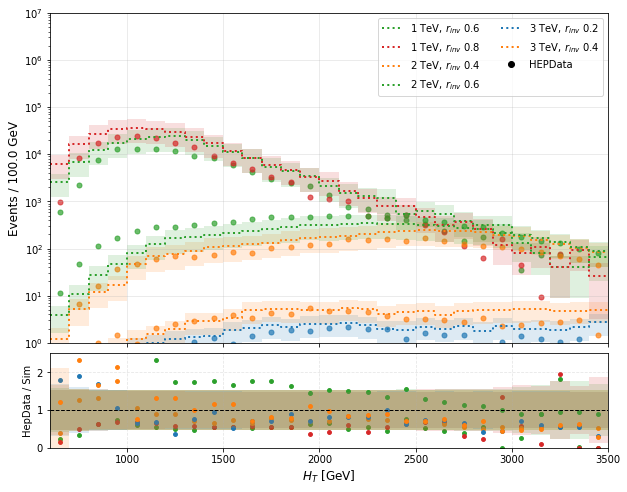


      WASSERSTEIN DISTANCE SUMMARY      
Average WD for 'pu': 100.5859
Average WD for 'pu_run2': No valid comparisons.
----------------------------------------

--- Processing met ---


/tmp/ipykernel_32458/2979026167.py:494: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


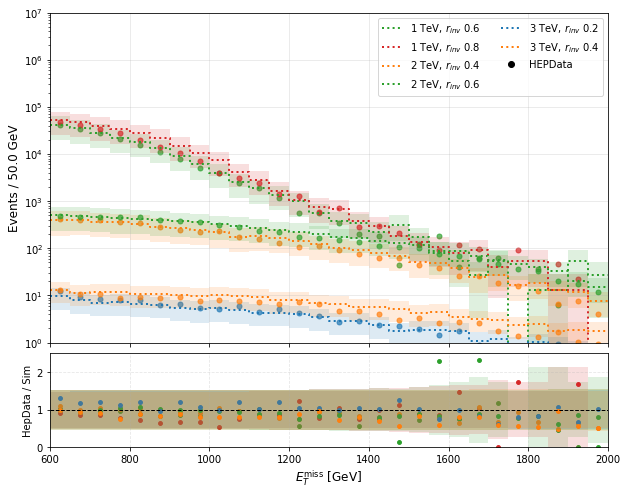


      WASSERSTEIN DISTANCE SUMMARY      
Average WD for 'pu': 22.4043
Average WD for 'pu_run2': No valid comparisons.
----------------------------------------

--- Processing delta_phi_j1j2 ---


/tmp/ipykernel_32458/2979026167.py:494: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


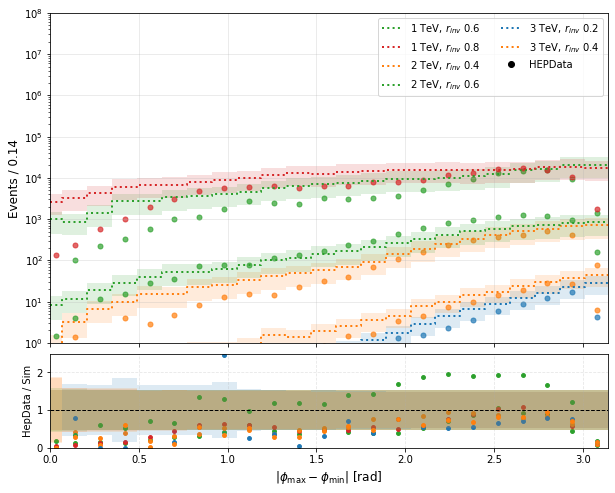


      WASSERSTEIN DISTANCE SUMMARY      
Average WD for 'pu': 0.1221
Average WD for 'pu_run2': No valid comparisons.
----------------------------------------

--- Processing pt_balance ---


/tmp/ipykernel_32458/2979026167.py:494: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


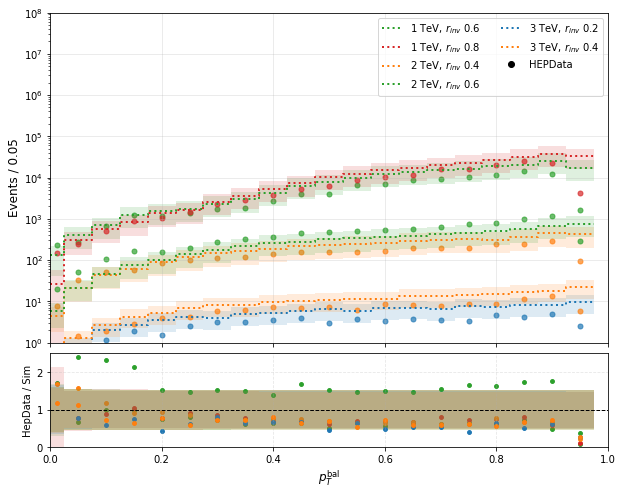


      WASSERSTEIN DISTANCE SUMMARY      
Average WD for 'pu': 0.0330
Average WD for 'pu_run2': No valid comparisons.
----------------------------------------



In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import awkward as ak
import pandas as pd
import numpy as np
import io
import re
import os
from scipy.stats import wasserstein_distance # <-- NEW IMPORT

# ==========================================
# 1. CONFIGURATION & CONSTANTS
# ==========================================
LUMI = 139  # fb^-1
N_GEN = 100000 # Make sure this matches your initial generated events BEFORE cuts
OUTPUT_BASE = "Analysis_Output_ver2"
REGION = "SR" # The directory region you want to plot

# Map your new analysis script's variable names to the plotting script's requested names
VAR_MAPPING = {
    'ht': 'ht',
    'met': 'met_recalc_pt',
    'delta_phi_j1j2': 'dphi_j1_j2',
    'pt_balance': 'pt_bal'
}

detector_type = "PileUp"  # Change to "PileUp" if you want to plot the pile-up scenario

if detector_type == "nonPileUp":
    code_default = "default"
    code_run2 = "run2"
elif detector_type == "PileUp":
    code_default = "pu"
    code_run2 = "pu_run2"

# Map your new processing tags to the physical modes for Metadata/HEPData lookup
TARGET_TAGS = {
    "bsm_1000_6_" + code_default: "1000_6",
    # "bsm_1000_6_" + code_run2: "1000_6",
    "bsm_1000_8_" + code_default: "1000_8",
    # "bsm_1000_8_" + code_run2: "1000_8",
    "bsm_2000_4_" + code_default: "2000_4",
    # "bsm_2000_4_" + code_run2: "2000_4",
    "bsm_2000_6_" + code_default: "2000_6",
    # "bsm_2000_6_" + code_run2: "2000_6",
    "bsm_3000_2_" + code_default: "3000_2",
    # "bsm_3000_2_" + code_run2: "3000_2",
    "bsm_3000_4_" + code_default: "3000_4",
    # "bsm_3000_4_" + code_run2: "3000_4",
}

# Plotting Styles (Color, Linestyle)
# STYLES = {
#     '1000_2': ('#1f77b4', '-'),  '1000_4': ('#ff7f0e', '-'),
#     '1000_6': ('#ff7f0e', '--'), '1000_8': ('#2ca02c', ':'),
#     '2000_2': ('#2ca02c', '-'), '2000_4': ('#d62728', ':'),  
#     '2000_6': ('#1f77b4', '-.'), '2000_8': ('#9467bd', '--'),
#     '3000_2': ('#9467bd', '-.'), '3000_4': ('#8c564b', '-.'),
#     '3000_6': ('#e377c2', '-.'), '3000_8': ('#7f7f7f', '-.')
# }

STYLES = {
    # 1000 series: Solid lines ('-')
    '1000_2': ('#1f77b4', '-'),   # Blue
    '1000_4': ('#ff7f0e', '-'),   # Orange
    '1000_6': ('#2ca02c', '-'),   # Green
    '1000_8': ('#d62728', '-'),   # Red

    # 2000 series: Dashed lines ('--')
    '2000_2': ('#1f77b4', '--'),  # Blue
    '2000_4': ('#ff7f0e', '--'),  # Orange
    '2000_6': ('#2ca02c', '--'),  # Green
    '2000_8': ('#d62728', '--'),  # Red

    # 3000 series: Dotted lines (':')
    '3000_2': ('#1f77b4', ':'),   # Blue
    '3000_4': ('#ff7f0e', ':'),   # Orange
    '3000_6': ('#2ca02c', ':'),   # Green
    '3000_8': ('#d62728', ':'),   # Red
}


# ==========================================
# UPDATED METADATA (Pythia Effective XS in fb)
# ==========================================
METADATA_LIST = [
    {"Mass": 1000, "Rinv": 2, "XS": 9551.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 4, "XS": 9540.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 6, "XS": 9552.0, "TheoryUnc": 0.52},
    {"Mass": 1000, "Rinv": 8, "XS": 9554.0, "TheoryUnc": 0.52},
    
    {"Mass": 2000, "Rinv": 2, "XS": 146.3, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 4, "XS": 146.8, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 6, "XS": 146.1, "TheoryUnc": 0.53},
    {"Mass": 2000, "Rinv": 8, "XS": 145.3, "TheoryUnc": 0.53},
    
    {"Mass": 3000, "Rinv": 2, "XS": 14.24, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 4, "XS": 14.20, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 6, "XS": 14.21, "TheoryUnc": 0.48},
    {"Mass": 3000, "Rinv": 8, "XS": 14.26, "TheoryUnc": 0.48},
]
DF_META = pd.DataFrame(METADATA_LIST)

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def get_hepdata_dict(filename):
    """Parses HEPData CSV into a dictionary of DataFrames."""
    if not os.path.exists(filename):
        print(f"Error: HEPData file {filename} not found.")
        return {}

    with open(filename, 'r') as f:
        content = f.read()
    
    blocks = content.strip().split('\n\n')
    data_dict = {}
    
    for block in blocks:
        lines = [l for l in block.split('\n') if not l.strip().startswith('#:')]
        if not lines: continue
        
        df = pd.read_csv(io.StringIO('\n'.join(lines)))
        df.columns = [c.strip() for c in df.columns]
        
        sig_col = next((c for c in df.columns if "Signal" in c), None)
        
        if sig_col:
            match = re.search(r'Signal \((\d+) TeV.* ([0-9\.]+)\)', sig_col)
            if match:
                mass_tev, r_val = match.groups()
                mass_gev = int(mass_tev) * 1000
                key_name = f"{mass_gev}_{r_val.replace('0.', '')[-1]}" 
                data_dict[key_name] = df
            else:
                data_dict[sig_col] = df
                
    return data_dict

def get_metadata(mode):
    """Retrieves XS and Theory Uncertainty based on mode string."""
    try:
        parts = mode.split('_')
        mass = int(parts[0])
        rinv = int(parts[1])
        row = DF_META[(DF_META['Mass'] == mass) & (DF_META['Rinv'] == rinv)]
        return row.iloc[0]['XS'], row.iloc[0]['TheoryUnc']
    except (IndexError, ValueError):
        print(f"Warning: Metadata not found for {mode}")
        return 1.0, 0.0
    
# ==========================================
# 3. MAIN PLOTTING FUNCTION
# ==========================================
# def compare_simulation_with_hepdata(
#     var_name,           
#     hepdata_file,       
#     xlabel,             
#     norm_val,           
#     x_limits,           
#     y_limits=(0.01, 1e5)
# ):
#     print(f"--- Processing {var_name} ---")

#     # Get the corresponding awkward array variable name
#     new_var_name = VAR_MAPPING.get(var_name, var_name)

#     # 1. Load HEPData Reference
#     hep_data = get_hepdata_dict(hepdata_file)
#     if not hep_data: return

#     # 2. Extract Bin Edges
#     ref_key = list(hep_data.keys())[0]
#     ref_df = hep_data[ref_key]
#     bin_edges = np.concatenate([ref_df.iloc[:, 1].values, [ref_df.iloc[:, 2].values[-1]]])
#     bin_widths = np.diff(bin_edges)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#     # 3. Setup Plot
#     fig = plt.figure(figsize=(10, 8))
#     gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.05)
#     ax_main = plt.subplot(gs[0])
#     ax_ratio = plt.subplot(gs[1], sharex=ax_main)

#     for tag, mode in TARGET_TAGS.items():
#         # --- A. Load Simulation ---

#         path_final = os.path.join(OUTPUT_BASE, REGION, f"{tag}.parquet")
        
#         card_mode = tag.split('_')[-1]  # Extract the middle part of the tag for mode matching
#         if not os.path.exists(path_final):
#             print(f"File not found: {path_final}")
#             continue
        
#         # Load the parquet file using awkward
#         events = ak.from_parquet(path_final)
        
#         # Ensure variable exists
#         if new_var_name not in events.fields:
#             print(f"Variable {new_var_name} not found in {path_final}")
#             continue
            
#         # Convert the specific column to a flat NumPy array for histogramming
#         plot_data = ak.to_numpy(events[new_var_name])

#         # Get Pythia Effective XS and Theory Uncertainty
#         xs_eff, theory_unc_frac = get_metadata(mode)
        
#         # Calculate Weights
#         norm_factor = (xs_eff * LUMI) / N_GEN 
#         normalized_weights = np.ones(len(plot_data)) * norm_factor

#         # --- B. Histogramming ---
#         # 1. Central Value
#         counts, _ = np.histogram(plot_data, bins=bin_edges, weights=normalized_weights)
        
#         # 2. Statistical Variance (Sum of Weights Squared)
#         sum_w2, _ = np.histogram(plot_data, bins=bin_edges, weights=normalized_weights**2)
        
#         # Scale to differential cross section unit (Events / norm_val GeV)
#         scale_factor = (bin_widths / norm_val)
        
#         y_sim = counts / scale_factor
#         y_err_stat = np.sqrt(sum_w2) / scale_factor
        
#         # 3. Add Theoretical Uncertainty
#         y_err_theory = y_sim * theory_unc_frac
        
#         # Total Error (Quadrature sum of Stat + Theory)
#         y_err_total = np.sqrt(y_err_stat**2 + y_err_theory**2)

#         # --- C. Plotting Main Pad ---
#         c, ls = STYLES.get(mode, ('black', '-'))
        
#         parts = mode.split('_')
#         mass_tev = int(parts[0]) // 1000
#         rinv_val = parts[1]
#         label_txt = f"{mass_tev} TeV, $r_{{inv}}$ 0.{rinv_val}"

#         if card_mode == "default":
#             ls = '-'  # Solid for default
#         elif card_mode == "run2":
#             ls = '--'  # Dashed for Run2
#         elif card_mode == "pu":
#             ls = ':'   # Dotted for PileUp
#         elif card_mode == "pu_run2":
#             ls = '-.'  # Dash-dot for PileUp + Run2
        
#         # Main Line
#         ax_main.step(bin_edges, np.append(y_sim, y_sim[-1]), where='post', 
#                      label=label_txt, color=c, linestyle=ls, linewidth=2)
        
#         # Shaded Band (Total Uncertainty)
#         y_sim_step = np.append(y_sim, y_sim[-1])
#         y_err_step = np.append(y_err_total, y_err_total[-1])
        
#         ax_main.fill_between(bin_edges, 
#                              y_sim_step - y_err_step,
#                              y_sim_step + y_err_step,
#                              step='post', color=c, alpha=0.15, edgecolor='none')

#         # --- D. Plotting Ratio Pad ---
#         if mode in hep_data:
#             ref_df = hep_data[mode]
#             y_col = [col for col in ref_df.columns if "Signal" in col][0]
#             y_ref = ref_df[y_col].values
            
#             # Plot Ref Points on Main Pad
#             ax_main.scatter(bin_centers, y_ref, color=c, marker='o', s=25, alpha=0.7)

#             # Calculate Ratio
#             valid_bins = y_sim > 0
#             ratio = np.zeros_like(y_ref)
#             ratio[valid_bins] = y_ref[valid_bins] / y_sim[valid_bins]
            
#             # Ratio Points
#             ax_ratio.scatter(bin_centers[valid_bins], ratio[valid_bins], color=c, marker='o', s=15)
            
#             # Ratio Uncertainty Band 
#             rel_err = np.zeros_like(y_sim)
#             rel_err[valid_bins] = y_err_total[valid_bins] / y_sim[valid_bins]
            
#             rel_err_step = np.append(rel_err, rel_err[-1])
#             ax_ratio.fill_between(bin_edges, 
#                                   1.0 - rel_err_step, 
#                                   1.0 + rel_err_step,
#                                   step='post', color=c, alpha=0.15, edgecolor='none')

#     # 4. Styling
#     ylabel = f"Events / {norm_val} GeV" if norm_val >= 1 else f"Events / {norm_val}"
    
#     ax_main.set_yscale('log')
#     ax_main.set_ylabel(ylabel, fontsize=12)
#     ax_main.set_xlim(*x_limits)
#     ax_main.set_ylim(*y_limits)
#     plt.setp(ax_main.get_xticklabels(), visible=False)
    
#     # Legend
#     handles, labels = ax_main.get_legend_handles_labels()
#     dummy_dot = Line2D([0], [0], marker='o', color='black', linestyle='None', label='HEPData')
#     handles.append(dummy_dot)
#     ax_main.legend(handles=handles, ncol=2, fontsize=10, loc='upper right')
    
#     # Ratio Styling
#     ax_ratio.set_ylabel("HepData / Sim", fontsize=10)
#     ax_ratio.set_xlabel(xlabel, fontsize=12)
#     ax_ratio.set_xlim(*x_limits)
#     ax_ratio.set_ylim(0.0, 2.5)
#     ax_ratio.axhline(1.0, color='black', linestyle='--', linewidth=1)
#     ax_ratio.grid(True, which="both", ls="--", alpha=0.3)
#     ax_main.grid(True, which="major", ls="-", alpha=0.3)

#     plt.tight_layout()
#     os.makedirs("plots", exist_ok=True)
#     plt.savefig(f"plots/comparison_{var_name}.pdf")
#     plt.show()

def compare_simulation_with_hepdata(
    var_name,           
    hepdata_file,       
    xlabel,             
    norm_val,           
    x_limits,           
    y_limits=(0.01, 1e5)
):
    print(f"--- Processing {var_name} ---")

    # Get the corresponding awkward array variable name
    new_var_name = VAR_MAPPING.get(var_name, var_name)

    # 1. Load HEPData Reference
    hep_data = get_hepdata_dict(hepdata_file)
    if not hep_data: return

    # 2. Extract Bin Edges
    ref_key = list(hep_data.keys())[0]
    ref_df = hep_data[ref_key]
    bin_edges = np.concatenate([ref_df.iloc[:, 1].values, [ref_df.iloc[:, 2].values[-1]]])
    bin_widths = np.diff(bin_edges)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # --- NEW: Dictionary to track Wasserstein distances ---
    wd_metrics = {code_default: [], code_run2: []}

    # 3. Setup Plot
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1], hspace=0.05)
    ax_main = plt.subplot(gs[0])
    ax_ratio = plt.subplot(gs[1], sharex=ax_main)

    for tag, mode in TARGET_TAGS.items():
        # --- A. Load Simulation ---
        path_final = os.path.join(OUTPUT_BASE, REGION, f"{tag}.parquet")
        
        card_mode = tag.split('_')[-1]  # Extract the middle part of the tag for mode matching
        if not os.path.exists(path_final):
            print(f"File not found: {path_final}")
            continue
        
        # Load the parquet file using awkward
        events = ak.from_parquet(path_final)
        
        # Ensure variable exists
        if new_var_name not in events.fields:
            print(f"Variable {new_var_name} not found in {path_final}")
            continue
            
        # Convert the specific column to a flat NumPy array for histogramming
        plot_data = ak.to_numpy(events[new_var_name])

        # Get Pythia Effective XS and Theory Uncertainty
        xs_eff, theory_unc_frac = get_metadata(mode)
        
        # Calculate Weights
        norm_factor = (xs_eff * LUMI) / N_GEN 
        normalized_weights = np.ones(len(plot_data)) * norm_factor

        # --- B. Histogramming ---
        # 1. Central Value
        counts, _ = np.histogram(plot_data, bins=bin_edges, weights=normalized_weights)
        
        # 2. Statistical Variance (Sum of Weights Squared)
        sum_w2, _ = np.histogram(plot_data, bins=bin_edges, weights=normalized_weights**2)
        
        # Scale to differential cross section unit (Events / norm_val GeV)
        scale_factor = (bin_widths / norm_val)
        
        y_sim = counts / scale_factor
        y_err_stat = np.sqrt(sum_w2) / scale_factor
        
        # 3. Add Theoretical Uncertainty
        y_err_theory = y_sim * theory_unc_frac
        
        # Total Error (Quadrature sum of Stat + Theory)
        y_err_total = np.sqrt(y_err_stat**2 + y_err_theory**2)

        # --- C. Plotting Main Pad ---
        c, ls = STYLES.get(mode, ('black', '-'))
        
        parts = mode.split('_')
        mass_tev = int(parts[0]) // 1000
        rinv_val = parts[1]
        label_txt = f"{mass_tev} TeV, $r_{{inv}}$ 0.{rinv_val}"

        if card_mode == "default":
            ls = '-'  # Solid for default
        elif card_mode == "run2":
            ls = '--'  # Dashed for Run2
        elif card_mode == "pu":
            ls = ':'   # Dotted for PileUp
        elif card_mode == "pu_run2":
            ls = '-.'  # Dash-dot for PileUp + Run2
        
        # Main Line
        ax_main.step(bin_edges, np.append(y_sim, y_sim[-1]), where='post', 
                     label=label_txt, color=c, linestyle=ls, linewidth=2)
        
        # Shaded Band (Total Uncertainty)
        y_sim_step = np.append(y_sim, y_sim[-1])
        y_err_step = np.append(y_err_total, y_err_total[-1])
        
        ax_main.fill_between(bin_edges, 
                             y_sim_step - y_err_step,
                             y_sim_step + y_err_step,
                             step='post', color=c, alpha=0.15, edgecolor='none')

        # --- D. Plotting Ratio Pad ---
        if mode in hep_data:
            ref_df = hep_data[mode]
            y_col = [col for col in ref_df.columns if "Signal" in col][0]
            y_ref = ref_df[y_col].values
            
            # Plot Ref Points on Main Pad
            ax_main.scatter(bin_centers, y_ref, color=c, marker='o', s=25, alpha=0.7)

            # Calculate Ratio
            valid_bins = y_sim > 0
            ratio = np.zeros_like(y_ref)
            ratio[valid_bins] = y_ref[valid_bins] / y_sim[valid_bins]
            
            # Ratio Points
            ax_ratio.scatter(bin_centers[valid_bins], ratio[valid_bins], color=c, marker='o', s=15)
            
            # Ratio Uncertainty Band 
            rel_err = np.zeros_like(y_sim)
            rel_err[valid_bins] = y_err_total[valid_bins] / y_sim[valid_bins]
            
            rel_err_step = np.append(rel_err, rel_err[-1])
            ax_ratio.fill_between(bin_edges, 
                                  1.0 - rel_err_step, 
                                  1.0 + rel_err_step,
                                  step='post', color=c, alpha=0.15, edgecolor='none')

            # --- NEW: Compute Wasserstein Distance ---
            # Ensure distributions are not completely empty to avoid NaN
            y_sim_clean = np.clip(y_sim, 0, None)
            y_ref_clean = np.clip(y_ref, 0, None)
            
            # Ensure distributions are not completely empty to avoid NaN
            if np.sum(y_sim_clean) > 0 and np.sum(y_ref_clean) > 0:
                wd = wasserstein_distance(bin_centers, bin_centers, u_weights=y_sim_clean, v_weights=y_ref_clean)
                
                # Assign to metric bucket based on the tag
                if code_run2 in tag:
                    wd_metrics[code_run2].append(wd)
                elif code_default in tag:
                    wd_metrics[code_default].append(wd)

    # 4. Styling
    ylabel = f"Events / {norm_val} GeV" if norm_val >= 1 else f"Events / {norm_val}"
    
    ax_main.set_yscale('log')
    ax_main.set_ylabel(ylabel, fontsize=12)
    ax_main.set_xlim(*x_limits)
    ax_main.set_ylim(*y_limits)
    plt.setp(ax_main.get_xticklabels(), visible=False)
    
    # Legend
    handles, labels = ax_main.get_legend_handles_labels()
    dummy_dot = Line2D([0], [0], marker='o', color='black', linestyle='None', label='HEPData')
    handles.append(dummy_dot)
    ax_main.legend(handles=handles, ncol=2, fontsize=10, loc='upper right')
    
    # Ratio Styling
    ax_ratio.set_ylabel("HepData / Sim", fontsize=10)
    ax_ratio.set_xlabel(xlabel, fontsize=12)
    ax_ratio.set_xlim(*x_limits)
    ax_ratio.set_ylim(0.0, 2.5)
    ax_ratio.axhline(1.0, color='black', linestyle='--', linewidth=1)
    ax_ratio.grid(True, which="both", ls="--", alpha=0.3)
    ax_main.grid(True, which="major", ls="-", alpha=0.3)

    plt.tight_layout()
    os.makedirs("plots", exist_ok=True)
    plt.savefig(f"plots/comparison_{var_name}.pdf")
    plt.show()

    # --- NEW: Summary Metrics Output ---
    print("\n" + "="*40)
    print("      WASSERSTEIN DISTANCE SUMMARY      ")
    print("="*40)
    
    avg_wd = {}
    for m_type in [code_default, code_run2]:
        dists = wd_metrics[m_type]
        if dists:
            avg_wd[m_type] = np.mean(dists)
            print(f"Average WD for '{m_type}': {avg_wd[m_type]:.4f}")
        else:
            print(f"Average WD for '{m_type}': No valid comparisons.")

    print("-" * 40)
    if code_default in avg_wd and code_run2 in avg_wd:
        if avg_wd[code_default] < avg_wd[code_run2]:
            print("CONCLUSION: '" + code_default + "' simulation is a closer match to HEPData (Lower WD).")
        elif avg_wd[code_run2] < avg_wd[code_default]:
            print("CONCLUSION: '" + code_run2 + "' simulation is a closer match to HEPData (Lower WD).")
        else:
            print("CONCLUSION: Both simulations are equally distant from the HEPData.")
    print("="*40 + "\n")
# ==========================================
# 4. EXECUTION
# ==========================================

# 1. Plot HT
compare_simulation_with_hepdata(
    var_name='ht',
    hepdata_file="HEPData-HT.csv",
    xlabel=r"$H_T$ [GeV]",
    norm_val=100.0,
    x_limits=(600, 3500),
    y_limits=(1, 1e7)
)

# 2. Plot MET (Mapped automatically to 'met_recalc_pt')
compare_simulation_with_hepdata(
    var_name='met',
    hepdata_file="HEPData-MET.csv",
    xlabel=r"$E^{\text{miss}}_T$ [GeV]",
    norm_val=50.0,
    x_limits=(600, 2000),
    y_limits=(1, 1e7)
)

# 3. Plot Delta Phi (Mapped automatically to 'dphi_j1_j2')
compare_simulation_with_hepdata(
    var_name='delta_phi_j1j2',
    hepdata_file="HEPData-phi.csv",
    xlabel=r"$|\phi_{\text{max}} - \phi_{\text{min}}|$ [rad]",
    norm_val=0.14,
    x_limits=(0, np.pi),
    y_limits=(1, 1e8)
)

# 4. Plot pT Balance (Mapped automatically to 'pt_bal')
compare_simulation_with_hepdata(
    var_name='pt_balance',
    hepdata_file="HEPData-pT.csv",
    xlabel=r"$p^{\text{bal}}_T$",
    norm_val=0.05,
    x_limits=(0, 1),
    y_limits=(1, 1e8)
)